# One table, from search to training

This notebook takes 3,000 COCO images through four steps on a single LanceDB table: **search** for unlabeled night street scenes with pedestrians, **tag** the curated slice as a named version, **add a column** computed in place, and **train** a model on the tagged version. There are no exports between the steps.

Raw image bytes, captions, metadata, embeddings and derived features all live in the same table, so search, curation, feature engineering and training all run on it.

It runs on a laptop CPU or in free Colab, with no GPU needed.

| Step | Section | What happens to the table |
|---|---|---|
| Search | 2 | Hybrid query returns rows, image bytes included |
| Tag a slice | 3 | Dedupe, materialize `night_peds`, tag `night-peds-v1` |
| Add a column | 4 | `quality` is computed in place; existing files stay as they are |
| Train a step | 5 | PyTorch reads `night-peds-v1` directly |

## 0. Setup

Install the packages, then connect to a local database folder. LanceDB is embedded, so `./data` is the whole database.

In [1]:
%pip install -q "lancedb==0.39.0" "pylance==12.0.0" "geneva==0.17.0" "open-clip-torch==3.3.0" "huggingface_hub>=0.34" matplotlib

Note: you may need to restart the kernel to use updated packages.

In [2]:
import os

os.environ.setdefault("TQDM_DISABLE", "1")      # keep progress bars out of the saved outputs
os.environ.setdefault("LANCE_LOG", "error")     # quiet Lance's Rust logs, including in Ray workers
os.environ.setdefault("LANCEDB_LOG", "error")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_VERBOSITY", "error")

import contextlib
import hashlib
import io
import json
import re
import shutil
import textwrap
import time
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import geneva
import lance
import lancedb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import torch
from huggingface_hub import snapshot_download
from IPython.display import Image as IPImage, display
from IPython.utils.capture import capture_output
from lancedb.embeddings import get_registry
from lancedb.index import FTS
from lancedb.pydantic import LanceModel, Vector
from PIL import Image, ImageEnhance

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_colwidth", 80)

print("lancedb", lancedb.__version__, "| pylance", lance.__version__, "| geneva", geneva.__version__, "| torch", torch.__version__)

lancedb 0.39.0 | pylance 12.0.0 | geneva 0.17.0 | torch 2.14.1


In [3]:
DATA_DIR = Path("./data").resolve()        # the LanceDB database
CACHE_DIR = Path("./.cache").resolve()     # downloaded dataset, reused across runs
CHECKPOINT_DIR = Path("./checkpoints").resolve()

# Start from an empty database on every run so the version numbers below are predictable.
shutil.rmtree(DATA_DIR, ignore_errors=True)
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

db = lancedb.connect(
    DATA_DIR,
    read_consistency_interval=timedelta(0),                          # always read the latest version
    storage_options={"new_table_enable_stable_row_ids": "true"},     # required for materialized views
)

# The same call against LanceDB Enterprise:
# db = lancedb.connect("db://your-database", api_key=os.environ["LANCEDB_API_KEY"], region="us-east-1", host_override="https://your-enterprise-endpoint")

print(db)

LanceDBConnection(uri='/Users/taylor/Documents/GitHub/lancedb-search-curate-train/data')


On LanceDB Enterprise the search, write and tag calls below stay the same; the notes at the end list the few local-only calls and their Enterprise equivalents.

In [4]:
# LanceDB Functions run as Geneva jobs. Locally, Geneva starts one Ray instance on this machine and reuses it.
fn_db = geneva.connect(str(DATA_DIR))
ray_session = contextlib.ExitStack()
ray_session.enter_context(fn_db.local_ray_context())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding device:", DEVICE)

Initializing Ray cluster. This could take a few minutes, especially if there are lots of dependencies to install.


2026-10-05 10:53:11,558	WARNING authentication_token_setup.py:85 -- Token authentication is enabled for this Ray cluster. Set RAY_AUTH_MODE=disabled to opt out. For more information, see https://docs.ray.io/en/latest/ray-security/token-auth.html


2026-10-05 10:53:18,354	INFO worker.py:2024 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Embedding device: cpu


Plotting helpers used by the visuals below.

In [5]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "figure.dpi": 90, "axes.titlecolor": INK, "axes.titlelocation": "left",
})


def show_images(rows, title, ncols=4, subtitle=None, size=3.0):
    """Draw a grid of images straight from the `image` bytes column."""
    rows = list(rows)
    nrows = (len(rows) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * (size + 0.7)))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, row in zip(np.atleast_1d(axes).ravel(), rows):
        img = Image.open(io.BytesIO(row["image"])).convert("RGB")
        side = min(img.size)
        left, top = (img.width - side) // 2, (img.height - side) // 2
        ax.imshow(img.crop((left, top, left + side, top + side)).resize((256, 256)))
        caption = textwrap.fill(textwrap.shorten(row.get("caption", ""), 70, placeholder="..."), 34)
        ax.set_title(caption, fontsize=8, color=INK, loc="left", fontweight="normal")
        if subtitle:
            ax.text(0, -0.02, subtitle(row), transform=ax.transAxes, fontsize=8, color=INK_2, va="top")
    fig.suptitle(title, x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
    fig.tight_layout()
    buf = io.BytesIO()                                   # photos as JPEG keep the saved notebook small
    fig.savefig(buf, format="jpeg", dpi=80, pil_kwargs={"quality": 82})
    plt.close(fig)
    display(IPImage(data=buf.getvalue(), format="jpeg"))


def barh(labels, values, title, color=BLUE, xlabel="rows"):
    """Horizontal bar chart with the value printed at the end of each bar."""
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(labels) + 1))
    y = np.arange(len(labels))[::-1]
    ax.barh(y, values, color=color, height=0.55)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    for yi, v in zip(y, values):
        ax.text(v, yi, f"  {v:,}", va="center", color=INK, fontsize=9)
    ax.set_xlim(0, max(values) * 1.15)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def schema_frame(table_or_schema):
    """One row per column: name and Arrow type."""
    schema = table_or_schema if isinstance(table_or_schema, pa.Schema) else table_or_schema.schema
    return pd.DataFrame(
        [(f.name, str(f.type).replace("fixed_size_list<item: float>", "vector<float>")) for f in schema],
        columns=["column", "type"],
    )


def data_files(table):
    """Every data file in the table, with the columns it stores."""
    ds = lance.dataset(table.uri)
    names = {}
    for field in ds.lance_schema.fields():
        names[field.id()] = field.name()
        for child in field.children():
            names[child.id()] = field.name()
    records = []
    for frag in ds.get_fragments():
        for f in frag.metadata.data_files():
            cols = sorted({names[i] for i in f.fields if i in names}, key=list(names.values()).index)
            records.append({"fragment": frag.fragment_id, "file": f.path, "columns": ", ".join(cols),
                            "size_kb": round(f.file_size_bytes / 1024, 1)})
    return pd.DataFrame(records)

## 1. Build the table

We use 3,000 COCO val2017 images with their human-written captions. They come from a public Lance dataset on Hugging Face (about 525 MB, no login needed) and are cached in `./.cache`. We load 2,800 images now and keep 200 back to append later, as if they came from a new drive.

In [6]:
NUM_IMAGES = 3_000     # up to 5,000; more images means a longer embedding step on CPU

coco_dir = snapshot_download(
    "lance-format/coco-captions-2017-lance",
    repo_type="dataset",
    allow_patterns=["data/val.lance/*"],
    local_dir=CACHE_DIR / "coco-captions-2017-lance",
)
coco = (
    lance.dataset(f"{coco_dir}/data/val.lance")
    .to_table(columns=["id", "image", "filename", "caption", "captions"])
    .sort_by("id")
    .slice(0, NUM_IMAGES)
)
print(f"{coco.num_rows:,} images, {coco.nbytes / 1e6:,.0f} MB")

3,000 images, 313 MB


We register OpenCLIP ViT-B-32 (`laion2b_s34b_b79k`) as the table's embedding function. The table computes `clip_emb` from the image bytes when rows are added, and embeds text queries with the same model at search time.

In [7]:
clip = get_registry().get("open-clip").create(name="ViT-B-32", pretrained="laion2b_s34b_b79k", device=DEVICE)


class Camera(LanceModel):
    width: int
    height: int
    mode: str        # PIL color mode, e.g. RGB or L (grayscale)
    file_name: str   # original COCO file name


class ImageRow(LanceModel):
    id: int
    image: bytes = clip.SourceField()                  # raw JPEG bytes
    caption: str                                       # first human caption, for display
    captions: list[str]                                # all 5 to 7 captions, for full-text search
    camera: Camera
    label: str | None = None                           # null means "not labeled yet"
    clip_emb: Vector(clip.ndims()) = clip.VectorField()


schema_frame(ImageRow.to_arrow_schema())

,column,type
0,id,int64
1,image,binary
2,caption,string
3,captions,list<item: string>
4,camera,"struct<width: int64 not null, height: int64 not null, mode: string not null,..."
5,label,string
6,clip_emb,vector<float>[512]


Most rows stay unlabeled. A random 8% get a label (`person` or `no_person`) to stand in for an earlier annotation pass. Here the labels come from the captions, which people wrote.

In [8]:
PERSON_WORDS = r"\b(person|people|man|men|woman|women|pedestrian|pedestrians|boy|girl|child|children|kid|kids|crowd|guy|lady)\b"
STREET_AT_NIGHT = r"\b(night|dark|evening)\b.*\b(street|road|city|traffic|crosswalk|sidewalk)\b|\b(street|road|city|traffic|crosswalk|sidewalk)\b.*\b(night|dark|evening)\b"

rng = np.random.default_rng(7)
caption_text = pd.Series([" ".join(c).lower() for c in coco["captions"].to_pylist()])


def caption_mentions_person(captions):
    return re.search(PERSON_WORDS, " ".join(captions).lower()) is not None


# Hold back 200 images for later: 40 street-at-night scenes plus 160 others, like a new night drive.
night_rows = np.flatnonzero(caption_text.str.contains(STREET_AT_NIGHT).to_numpy())
other_rows = np.setdiff1d(np.arange(coco.num_rows), night_rows)
held_back_rows = np.sort(np.concatenate([rng.choice(night_rows, 40, replace=False), rng.choice(other_rows, 160, replace=False)]))
initial = coco.take(np.setdiff1d(np.arange(coco.num_rows), held_back_rows))
held_back = coco.take(held_back_rows)          # appended in sections 4 and 6
labeled_ids = set(rng.choice(initial["id"].to_numpy(), size=int(0.08 * initial.num_rows), replace=False).tolist())


def make_rows(source: pa.Table) -> list[dict]:
    """Table rows without clip_emb: the table's embedding function fills it on insert."""
    rows = []
    for rec in source.to_pylist():
        img = Image.open(io.BytesIO(rec["image"]))      # reads the header only
        rows.append({
            "id": rec["id"],
            "image": rec["image"],
            "caption": rec["caption"].strip(),
            "captions": [c.strip() for c in rec["captions"]],
            "camera": {"width": img.width, "height": img.height, "mode": img.mode, "file_name": rec["filename"]},
            "label": ("person" if caption_mentions_person(rec["captions"]) else "no_person") if rec["id"] in labeled_ids else None,
        })
    return rows


tbl = db.create_table("images", schema=ImageRow, mode="overwrite")
start = time.time()
for offset in range(0, initial.num_rows, 700):        # four fragments of 700 rows
    tbl.add(make_rows(initial.slice(offset, 700)))
elapsed = time.time() - start
print(f"Embedded and loaded {tbl.count_rows():,} rows in {elapsed:.0f}s ({tbl.count_rows() / elapsed:.0f} images/s on {DEVICE}), table version {tbl.version}")

Embedded and loaded 2,800 rows in 31s (89 images/s on cpu), table version 5


Camera data often has bursts of near-identical frames. To simulate them, we add 150 copies of existing street scenes, each shifted by up to 1% and re-exposed by up to 3%.

In [9]:
def burst_frame(jpeg: bytes, seed: int) -> bytes:
    r = np.random.default_rng(seed)
    img = Image.open(io.BytesIO(jpeg)).convert("RGB")
    w, h = img.size
    dx, dy = int(w * r.uniform(0, 0.01)), int(h * r.uniform(0, 0.01))
    img = img.crop((dx, dy, w - dx, h - dy))
    img = ImageEnhance.Brightness(img).enhance(r.uniform(0.97, 1.03))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=90)
    return buf.getvalue()


initial_text = pd.Series([" ".join(c).lower() for c in initial["captions"].to_pylist()])
street_like = np.flatnonzero(initial_text.str.contains(r"\b(street|road|night|traffic|crosswalk|city|sidewalk)\b").to_numpy())
burst_source = rng.choice(street_like, size=150, replace=False)

burst_rows = []
for k, idx in enumerate(burst_source):
    copy = make_rows(initial.slice(int(idx), 1))[0]
    copy.update(id=10_000 + k, image=burst_frame(copy["image"], seed=k), label=None)
    copy["camera"]["file_name"] = f"burst_{k:03d}_" + copy["camera"]["file_name"]
    burst_rows.append(copy)

tbl.add(burst_rows)
print(f"Added {len(burst_rows)} burst copies; table now has {tbl.count_rows():,} rows")

Added 150 burst copies; table now has 2,950 rows


### Derive `brightness` with LanceDB Functions

We need a `brightness` value to make "low-light" queryable. LanceDB Functions are LanceDB's Python UDF columns: you declare a function, attach it as a column, and LanceDB backfills it. Function columns run on LanceDB Enterprise. **To run on a laptop or in Colab, this notebook uses the `geneva` package**, which has the same declare, attach, backfill pattern and runs it on the local Ray instance started above. The rest of the notebook calls these LanceDB Functions.

In [10]:
def backfill(column: str) -> None:
    """Run a LanceDB Functions backfill on the latest version of `images`; Geneva's progress bars are hidden."""
    with capture_output():
        fn_db.open_table("images").backfill(column, concurrency=4)
        time.sleep(1.5)   # let Ray flush the worker logs into the hidden output


@geneva.udf(data_type=pa.float32())
def brightness(image: bytes) -> float:
    """Mean luminance in [0, 1] of a 128px grayscale thumbnail."""
    import io
    import numpy as np
    from PIL import Image

    img = Image.open(io.BytesIO(image)).convert("L")
    img.thumbnail((128, 128))
    return float(np.asarray(img, dtype=np.float32).mean() / 255.0)


fn_db.open_table("images").add_columns({"brightness": brightness})
start = time.time()
backfill("brightness")
print(f"Backfilled brightness for {tbl.count_rows('brightness IS NOT NULL'):,} rows in {time.time() - start:.1f}s; table version {tbl.version}")

Backfilled brightness for 2,950 rows in 18.7s; table version 11


Last, a full-text index on the captions so the hybrid search in section 2 can match words like "pedestrian".

In [11]:
tbl.create_index("captions", config=FTS())
schema_frame(tbl)

,column,type
0,id,int64
1,image,binary
2,caption,string
3,captions,list<item: string>
4,camera,"struct<width: int64 not null, height: int64 not null, mode: string not null,..."
5,label,string
6,clip_emb,vector<float>[512]
7,brightness,float


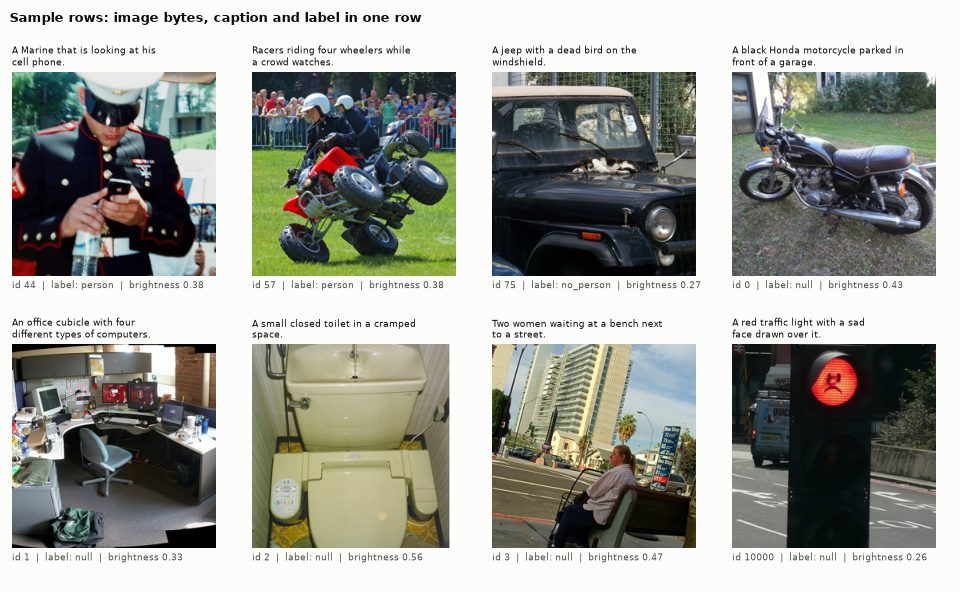

In [12]:
sample = pd.concat([
    tbl.search().where("label IS NOT NULL").limit(3).to_pandas(),
    tbl.search().where("label IS NULL AND id < 10000").limit(4).to_pandas(),
    tbl.search().where("id >= 10000").limit(1).to_pandas(),
])
show_images(
    sample.to_dict("records"),
    "Sample rows: image bytes, caption and label in one row",
    subtitle=lambda r: f"id {r['id']}  |  label: {'null' if pd.isna(r['label']) else r['label']}  |  brightness {r['brightness']:.2f}",
)

## 2. Search (slide 7)

We're looking for unlabeled night street scenes with pedestrians. One hybrid query combines CLIP vector search for "low-light street scene", BM25 full-text search for "pedestrian" over the captions, and a `label IS NULL` filter. The slide's one-line form runs as written:

In [13]:
slide_form = tbl.search("low-light street scene", query_type="hybrid").where("label IS NULL").limit(500).to_pandas()
print(f"{len(slide_form)} rows")

500 rows


That form sends one string to both sides of the search. To run full-text search on a different word, pass the vector text and the keyword separately. The table's embedding function turns the vector text into a CLIP embedding.

In [14]:
results = (
    tbl.search(query_type="hybrid")
    .vector("low-light street scene")    # CLIP text embedding, computed by the table
    .text("pedestrian")                  # BM25 over the captions column
    .where("label IS NULL")
    .limit(500)
    .to_pandas()
)

first = results.iloc[0]
print(f"{len(results)} rows, columns: {list(results.columns)}")
print(f"Top row id {first['id']}: image is {type(first['image']).__name__}, {len(first['image']):,} bytes, decoded size {Image.open(io.BytesIO(first['image'])).size}")

500 rows, columns: ['id', 'image', 'caption', 'captions', 'camera', 'label', 'clip_emb', 'brightness', '_relevance_score']
Top row id 1186: image is bytes, 91,007 bytes, decoded size (640, 426)


The image bytes come back in the result rows, so there's no second lookup against an object store.

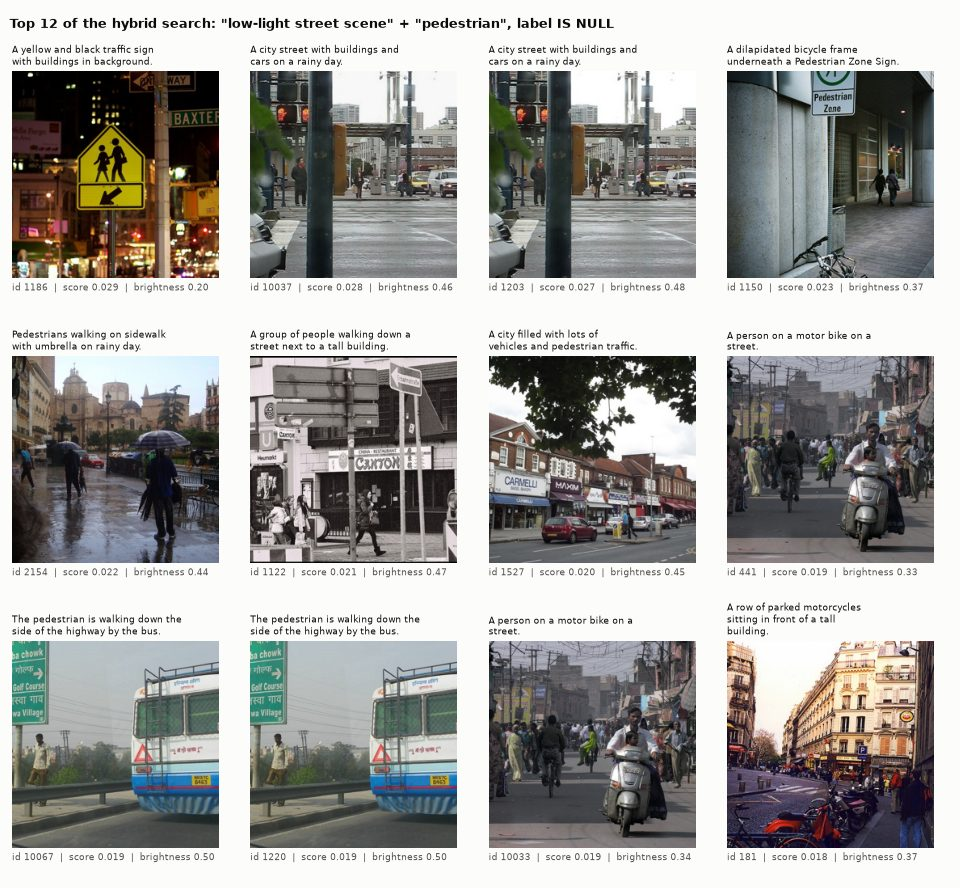

In [15]:
show_images(
    results.head(12).to_dict("records"),
    'Top 12 of the hybrid search: "low-light street scene" + "pedestrian", label IS NULL',
    subtitle=lambda r: f"id {r['id']}  |  score {r['_relevance_score']:.3f}  |  brightness {r['brightness']:.2f}",
)

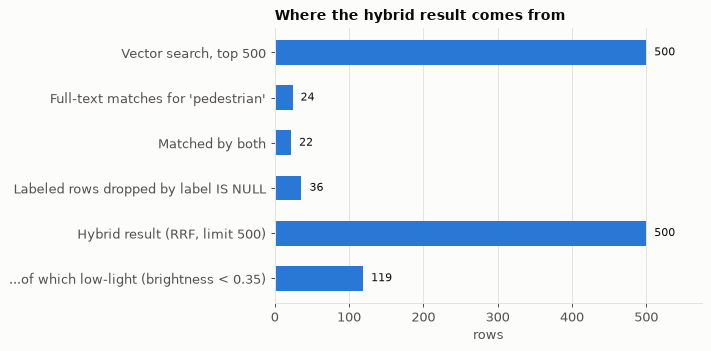

In [16]:
LOW_LIGHT = 0.35   # brightness threshold used for curation in section 3

vector_ids = set(tbl.search("low-light street scene", query_type="vector").where("label IS NULL").limit(500).to_pandas()["id"])
fts_ids = set(tbl.search("pedestrian", query_type="fts").where("label IS NULL").limit(500).to_pandas()["id"])
unfiltered = tbl.search(query_type="hybrid").vector("low-light street scene").text("pedestrian").limit(500).to_pandas()

barh(
    ["Vector search, top 500", "Full-text matches for 'pedestrian'", "Matched by both",
     "Labeled rows dropped by label IS NULL", "Hybrid result (RRF, limit 500)", f"...of which low-light (brightness < {LOW_LIGHT})"],
    [len(vector_ids), len(fts_ids), len(vector_ids & fts_ids), int(unfiltered["label"].notna().sum()),
     len(results), int((results["brightness"] < LOW_LIGHT).sum())],
    "Where the hybrid result comes from",
)

> **At scale.** On LanceDB Enterprise the same query runs on a cluster: query nodes plan it, executors read from object storage through an NVMe cache, and you add nodes for more query throughput or for tables that outgrow one machine. See [LanceDB Enterprise](https://docs.lancedb.com/enterprise) and its [architecture](https://docs.lancedb.com/enterprise/architecture).

## 3. Curate and tag a slice (slide 8)

The search results above include burst copies (ids 10000 and up) next to their originals. We dedupe by embedding distance, keep the low-light rows, and freeze the result as a materialized view called `night_peds` with a tag. The dedupe is another LanceDB Function: for each row it runs a vector search on the same table and records the id of any earlier row that is almost identical.

In [17]:
@geneva.udf(data_type=pa.int64())
class NearDuplicateOf:
    """Id of an earlier row within `max_distance` (cosine) of this row's clip_emb, else null."""

    def __init__(self, db_path: str, table_name: str = "images", max_distance: float = 0.06):
        self.db_path, self.table_name, self.max_distance = db_path, table_name, max_distance
        self.table = None

    def __call__(self, batch: pa.RecordBatch) -> pa.Array:
        import lancedb
        import numpy as np

        if self.table is None:
            self.table = lancedb.connect(self.db_path).open_table(self.table_name)
        duplicate_of = []
        for row_id, emb in zip(batch["id"].to_pylist(), batch["clip_emb"].to_numpy(zero_copy_only=False)):
            hits = (
                self.table.search(np.asarray(emb), vector_column_name="clip_emb")
                .distance_type("cosine")
                .where(f"id < {row_id}")
                .select(["id", "_distance"])
                .limit(1)
                .to_list()
            )
            duplicate_of.append(hits[0]["id"] if hits and hits[0]["_distance"] <= self.max_distance else None)
        return pa.array(duplicate_of, type=pa.int64())


fn_db.open_table("images").add_columns({"dup_of": NearDuplicateOf(db_path=str(DATA_DIR))})
start = time.time()
backfill("dup_of")
print(f"Backfilled dup_of in {time.time() - start:.1f}s: {tbl.count_rows('dup_of IS NOT NULL')} near-duplicates in {tbl.count_rows():,} rows")

Backfilled dup_of in 15.0s: 148 near-duplicates in 2,950 rows


Flagged 148 rows: 144 of the 150 burst copies, plus 4 near-identical shots that were already in COCO.


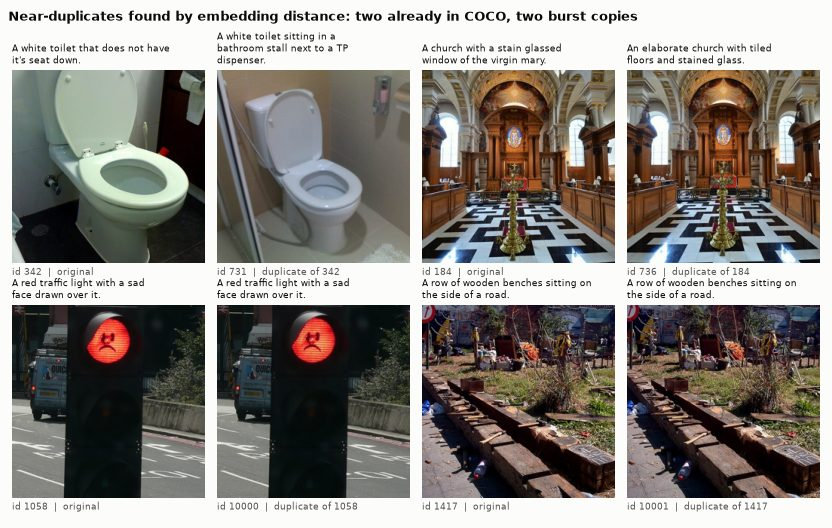

In [18]:
flagged = tbl.search().where("dup_of IS NOT NULL").select(["id", "dup_of"]).limit(10_000).to_pandas()
burst_flagged = int((flagged["id"] >= 10_000).sum())
print(f"Flagged {len(flagged)} rows: {burst_flagged} of the 150 burst copies, plus {len(flagged) - burst_flagged} near-identical shots that were already in COCO.")

pairs = pd.concat([
    tbl.search().where("dup_of IS NOT NULL AND id < 10000").select(["id", "dup_of", "image", "caption"]).limit(2).to_pandas(),
    tbl.search().where("dup_of IS NOT NULL AND id >= 10000").select(["id", "dup_of", "image", "caption"]).limit(2).to_pandas(),
])
originals = tbl.search().where(f"id IN ({','.join(map(str, pairs['dup_of']))})").select(["id", "image", "caption"]).to_pandas().set_index("id")
pair_rows = []
for _, dup in pairs.iterrows():
    pair_rows.append({**originals.loc[dup["dup_of"]].to_dict(), "id": int(dup["dup_of"]), "note": "original"})
    pair_rows.append({**dup.to_dict(), "note": f"duplicate of {dup['dup_of']}"})
show_images(pair_rows, "Near-duplicates found by embedding distance: two already in COCO, two burst copies", ncols=4, size=2.6,
            subtitle=lambda r: f"id {r['id']}  |  {r['note']}")

Record the search hits in the table as a boolean column. Adding a column from a SQL expression writes only that column. Then define the view: search hits that are low-light and not near-duplicates. The view also gets `has_person`, a weak label computed in SQL from the captions, which we train on in section 5.

In [19]:
hit_ids = ",".join(map(str, results["id"]))
tbl.add_columns({"in_night_peds": f"id IN ({hit_ids})"})

view = db.create_materialized_view(       # local databases only; see the notes at the end
    "night_peds",
    "images",
    select=[
        "id", "image", "caption", "captions", "camera", "label", "clip_emb", "brightness",
        ("has_person", f"regexp_like(lower(array_to_string(captions, ' ')), '{PERSON_WORDS}')"),
    ],
    where=f"in_night_peds AND dup_of IS NULL AND brightness < {LOW_LIGHT}",
)
refresh = view.refresh()
night_peds = view.table
print(refresh)

RefreshMaterializedViewResult(mode=rebuild, rows_written=103, source_version=18, version=3)


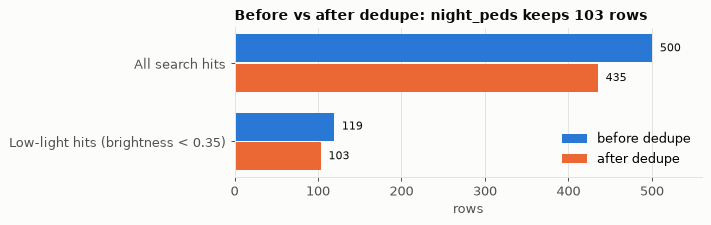

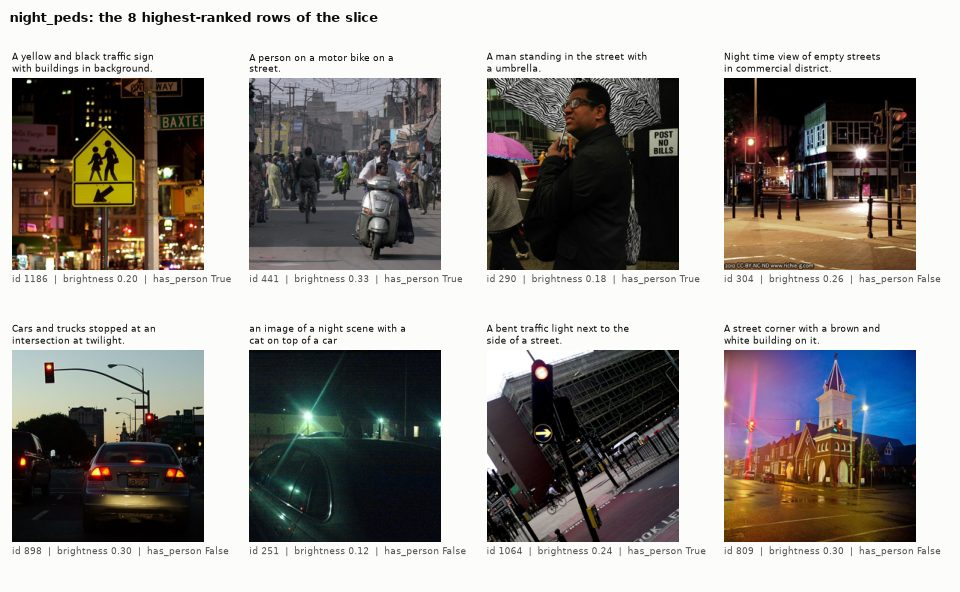

In [20]:
hits = results.assign(is_dup=results["id"].isin(set(tbl.search().where("dup_of IS NOT NULL").select(["id"]).limit(10_000).to_pandas()["id"])))
low_light_hits = hits[hits["brightness"] < LOW_LIGHT]

groups = ["All search hits", f"Low-light hits (brightness < {LOW_LIGHT})"]
before = [len(hits), len(low_light_hits)]
after = [int((~hits["is_dup"]).sum()), night_peds.count_rows()]
fig, ax = plt.subplots(figsize=(8, 2.6))
y = np.arange(len(groups))[::-1]
ax.barh(y + 0.19, before, height=0.36, color=BLUE, label="before dedupe")
ax.barh(y - 0.19, after, height=0.36, color=ORANGE, label="after dedupe")
for yi, b, a in zip(y, before, after):
    ax.text(b, yi + 0.19, f"  {b}", va="center", fontsize=9, color=INK)
    ax.text(a, yi - 0.19, f"  {a}", va="center", fontsize=9, color=INK)
ax.set_yticks(y, groups)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(before) * 1.12)
ax.set_xlabel("rows")
ax.legend(loc="lower right", frameon=False)
ax.set_title(f"Before vs after dedupe: night_peds keeps {night_peds.count_rows()} rows")
fig.tight_layout()
plt.show()

slice_rows = night_peds.search().limit(10_000).to_pandas()
top_of_slice = results[["id", "_relevance_score"]].merge(slice_rows, on="id").head(8)   # keeps search rank order
show_images(
    top_of_slice.to_dict("records"),
    "night_peds: the 8 highest-ranked rows of the slice",
    subtitle=lambda r: f"id {r['id']}  |  brightness {r['brightness']:.2f}  |  has_person {r['has_person']}",
)

Tag the version so it can be checked out by name. The slide's call runs as written, on the view's table:

In [21]:
night_peds.tags.create("night-peds-v1", night_peds.version)
tagged_version = night_peds.tags.get_version("night-peds-v1")
print(night_peds.tags.list())

{'night-peds-v1': {'version': 3, 'manifest_size': 2571}}


Now a later write: an annotator labels 20 rows of the slice in the source table, and the view refreshes incrementally. The tag still returns the rows as they were.

In [22]:
to_label = night_peds.search().select(["id", "captions"]).limit(20).to_pandas()
to_label["label"] = ["person" if caption_mentions_person(c) else "no_person" for c in to_label["captions"]]
for value, group in to_label.groupby("label"):
    tbl.update(where=f"id IN ({','.join(map(str, group['id']))})", values={"label": value})
print(view.refresh())

latest = night_peds.to_pandas().sort_values("id")
night_peds.checkout("night-peds-v1")
at_tag = night_peds.to_pandas().sort_values("id")
night_peds.checkout_latest()

pd.DataFrame({
    "version": [f"night-peds-v1 (v{tagged_version})", f"latest (v{night_peds.version})"],
    "rows": [len(at_tag), len(latest)],
    "labeled rows": [int(at_tag["label"].notna().sum()), int(latest["label"].notna().sum())],
    "same ids as tag": [True, at_tag["id"].tolist() == latest["id"].tolist()],
})

RefreshMaterializedViewResult(mode=incremental, rows_written=20, source_version=20, version=5)


,version,rows,labeled rows,same ids as tag
0,night-peds-v1 (v3),103,0,True
1,latest (v5),103,20,True


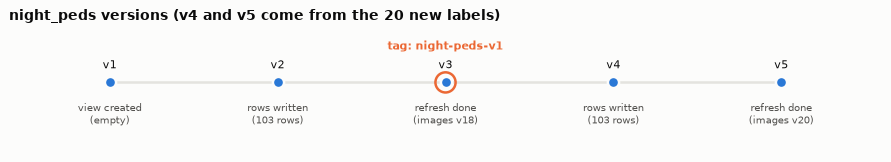

In [23]:
def version_timeline(table, events, tag_name, title):
    """Dots for each table version, labeled with what produced it, with the tag marked."""
    versions = [v["version"] for v in table.list_versions()]
    tag_v = table.tags.get_version(tag_name)
    fig, ax = plt.subplots(figsize=(10, 1.9))
    ax.plot(versions, [0] * len(versions), color=GRID, lw=2, zorder=1)
    ax.scatter(versions, [0] * len(versions), s=80, color=BLUE, zorder=2, edgecolor="#fcfcfb", linewidth=2)
    for v in versions:
        ax.text(v, 0.18, f"v{v}", ha="center", fontsize=9, color=INK)
        if v in events:
            ax.text(v, -0.25, textwrap.fill(events[v], 16), ha="center", va="top", fontsize=8, color=INK_2)
    ax.scatter([tag_v], [0], s=260, facecolor="none", edgecolor=ORANGE, linewidth=2, zorder=3)
    ax.text(tag_v, 0.42, f"tag: {tag_name}", ha="center", fontsize=9, color=ORANGE, fontweight="bold")
    ax.set_ylim(-0.9, 0.7)
    ax.set_xlim(min(versions) - 0.6, max(versions) + 0.6)
    ax.axis("off")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def view_events(table):
    """Describe each version of a materialized view: a refresh commits rows, then records the source version it read."""
    events, last_source = {}, None
    for v in table.list_versions():
        ds_v = lance.dataset(table.uri, version=v["version"])
        source = (ds_v.schema.metadata or {}).get(b"mv.source_version")
        if v["version"] == 1:
            events[1] = "view created (empty)"
        elif source != last_source:
            events[v["version"]] = f"refresh done (images v{source.decode()})"
        else:
            events[v["version"]] = f"rows written ({ds_v.count_rows()} rows)"
        last_source = source
    return events


version_timeline(night_peds, view_events(night_peds), "night-peds-v1", "night_peds versions (v4 and v5 come from the 20 new labels)")

## 4. Add a column (slide 9)

We add a `quality` score to every image, computed in place by a LanceDB Function that reads the image bytes. Before and after, we list the table's data files to check that no existing column was rewritten.

In [24]:
schema_before = schema_frame(tbl)
files_before = data_files(tbl)
version_before = tbl.version


@geneva.udf(data_type=pa.float32())
def quality(image: bytes) -> float:
    """Sharpness times exposure, in [0, 1]. Sharpness: variance of the Laplacian; exposure: distance from mid-gray."""
    import io
    import numpy as np
    from PIL import Image

    gray = Image.open(io.BytesIO(image)).convert("L")
    gray.thumbnail((256, 256))
    px = np.asarray(gray, dtype=np.float32) / 255.0
    lap = px[:-2, 1:-1] + px[2:, 1:-1] + px[1:-1, :-2] + px[1:-1, 2:] - 4 * px[1:-1, 1:-1]
    sharpness = lap.var() / (lap.var() + 0.002)
    exposure = 1.0 - abs(px.mean() - 0.5) * 2
    return float(sharpness * (0.5 + 0.5 * exposure))


fn_db.open_table("images").add_columns({"quality": quality})
start = time.time()
backfill("quality")
print(f"Backfilled quality for {tbl.count_rows('quality IS NOT NULL'):,} rows in {time.time() - start:.1f}s (v{version_before} -> v{tbl.version})")

Backfilled quality for 2,950 rows in 14.7s (v20 -> v25)


In [25]:
files_after = data_files(tbl)
files_after["status"] = np.where(files_after["file"].isin(files_before["file"]), "unchanged", "new")
new_files = files_after[files_after["status"] == "new"]

print(f"{len(files_before)} files before, {len(files_after)} after. Every file from before is still in place: "
      f"{files_before['file'].isin(files_after['file']).all()}")
print(f"Written by the backfill: {new_files['size_kb'].sum():,.0f} KB of new files, next to {files_before['size_kb'].sum() / 1024:,.0f} MB of existing data.")
(
    files_after.groupby(["columns", "status"], sort=False)
    .agg(files=("file", "count"), total_kb=("size_kb", "sum"))
    .reset_index()
    .rename(columns={"columns": "columns stored in the file"})
)

22 files before, 29 after. Every file from before is still in place: True
Written by the backfill: 31 KB of new files, next to 302 MB of existing data.


,columns stored in the file,status,files,total_kb
0,"id, image, caption, captions, camera, label, clip_emb",unchanged,5,306972.5
1,brightness,unchanged,5,29.5
2,dup_of,unchanged,5,19.5
3,in_night_peds,unchanged,5,3.0
4,quality,new,7,31.0
5,"id, image, caption, captions, camera, label, clip_emb, brightness, dup_of, i...",unchanged,2,2077.7


Next, append 8 new images. The table embeds them on insert and `quality` is null for those rows only. Running the same backfill again computes just those 8 (Geneva's default filter is `quality IS NULL`), and only the new fragment gets a new file.

In [26]:
quality_before_append = tbl.search().where("quality IS NOT NULL").select(["id", "quality"]).limit(100_000).to_pandas()
files_before_append = data_files(tbl)

new_rows = [dict(row, in_night_peds=False) for row in make_rows(held_back.slice(0, 8))]   # not in the slice yet
tbl.add(new_rows)       # no clip_emb: the table embeds the images on insert
print(f"Rows waiting for quality: {tbl.count_rows('quality IS NULL')}")

backfill("quality")
files_after_append = data_files(tbl)
added = files_after_append[~files_after_append["file"].isin(files_before_append["file"])]
quality_after_append = tbl.search().select(["id", "quality"]).limit(100_000).to_pandas()
unchanged = quality_before_append.merge(quality_after_append, on="id", suffixes=("_before", "_after"))

print(f"Rows waiting for quality after the backfill: {tbl.count_rows('quality IS NULL')}")
print(f"Existing quality values unchanged: {(unchanged['quality_before'] == unchanged['quality_after']).all()} ({len(unchanged):,} rows)")
added

Rows waiting for quality: 8


Rows waiting for quality after the backfill: 0
Existing quality values unchanged: True (2,950 rows)


,fragment,file,columns,size_kb
29,7,001010000111011011001001f326494c4198f1dc6cf9c79e04.lance,"id, image, caption, captions, camera, label, clip_emb, in_night_peds",801.6
30,7,8362a30a-951e-4343-a4e7-09e9694b651b.lance,quality,0.7


,column,before,after,change
0,id,int64,int64,
1,image,binary,binary,
2,caption,string,string,
3,captions,list<item: string>,list<item: string>,
4,camera,"struct<width: int64 not null, height: int64 not null, mode: string not null,...","struct<width: int64 not null, height: int64 not null, mode: string not null,...",
5,label,string,string,
6,clip_emb,vector<float>[512],vector<float>[512],
7,brightness,float,float,
8,dup_of,int64,int64,
9,in_night_peds,bool,bool,


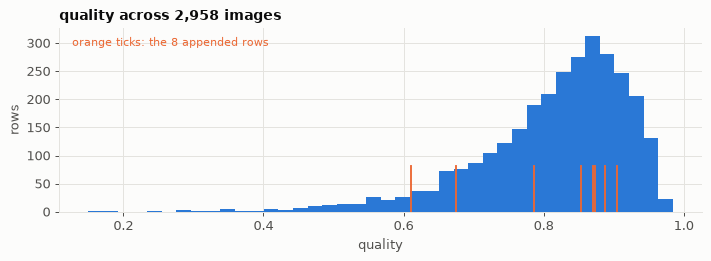

In [27]:
schema_after = schema_frame(tbl)
compare = schema_after.merge(schema_before, on="column", how="left", suffixes=("", "_before"))
compare["before"] = compare["type_before"].fillna("")
compare["after"] = compare["type"]
compare["change"] = np.where(compare["type_before"].isna(), "added", "")
display(compare[["column", "before", "after", "change"]])

all_quality = tbl.search().select(["id", "quality"]).limit(100_000).to_pandas()
new_quality = all_quality[all_quality["id"].isin([r["id"] for r in new_rows])]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(all_quality["quality"], bins=40, color=BLUE)
for q in new_quality["quality"]:
    ax.axvline(q, color=ORANGE, lw=1.5, ymax=0.25)
ax.text(0.02, 0.9, "orange ticks: the 8 appended rows", transform=ax.transAxes, color=ORANGE, fontsize=9)
ax.set_xlabel("quality")
ax.set_ylabel("rows")
ax.set_title(f"quality across {len(all_quality):,} images")
fig.tight_layout()
plt.show()

> **At scale.** On LanceDB Enterprise the same `backfill` call submits a distributed job, run with checkpoints so a failed job resumes without recomputing finished work. With `auto_backfill=True` on the UDF, Enterprise recomputes the column when new rows land, so the second backfill call above isn't needed. See [Geneva backfills](https://docs.lancedb.com/geneva/jobs/backfilling).

## 5. Train a step (slide 10)

PyTorch reads the tagged version of `night_peds` directly from the table. We train a linear probe on `clip_emb` that predicts the weak `has_person` label, then save a checkpoint that records which table version it was trained on.

In [28]:
from lance.sampler import ShardedBatchSampler
from lance.torch.data import LanceDataset
from torch.utils.data import DataLoader

uri = night_peds.uri
ds = lance.dataset(uri, version="night-peds-v1")
loader = DataLoader(
    LanceDataset(
        ds,
        batch_size=64,
        columns=["clip_emb", "has_person"],
        sampler=ShardedBatchSampler(rank=0, world_size=1, randomize=True, seed=0),   # shuffles batch order
    ),
    batch_size=None,   # LanceDataset already yields batches of 64
)

batch = next(iter(loader))
print(f"Training on {ds.count_rows()} rows of {Path(uri).name} at version {ds.version}")
print({name: tuple(t.shape) for name, t in batch.items()})

Training on 103 rows of night_peds.lance at version 3
{'clip_emb': (64, 512), 'has_person': (64,)}


In [29]:
torch.manual_seed(0)
probe = torch.nn.Linear(512, 1)
optimizer = torch.optim.Adam(probe.parameters(), lr=0.01)
loss_fn = torch.nn.BCEWithLogitsLoss()

losses = []
for epoch in range(15):
    loader.dataset.sampler.set_epoch(epoch)
    for batch in loader:
        logits = probe(batch["clip_emb"].float()).squeeze(1)
        loss = loss_fn(logits, batch["has_person"].float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
print(f"{len(losses)} steps, final loss {losses[-1]:.3f}")

30 steps, final loss 0.448


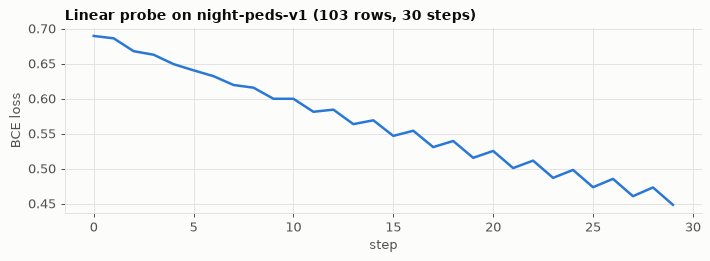

,checkpoint,table,tag,version,rows,data fingerprint,held-out accuracy
0,night_peds_probe.pt,night_peds,night-peds-v1,3,103,a8ab0010ab30aaee,81% on 224 labeled rows


In [30]:
def fingerprint(dataset) -> str:
    """Hash of the exact training rows: ids, embeddings and targets, in id order."""
    t = dataset.to_table(columns=["id", "clip_emb", "has_person"]).sort_by("id")
    h = hashlib.sha256()
    for name in t.column_names:
        h.update(np.ascontiguousarray(t[name].combine_chunks().flatten() if name == "clip_emb" else t[name].to_numpy()).tobytes())
    return h.hexdigest()


def evaluate(model, dataset) -> float:
    t = dataset.to_table(columns=["clip_emb", "has_person"])
    x = torch.tensor(np.stack(t["clip_emb"].to_numpy(zero_copy_only=False)))
    y = torch.tensor(t["has_person"].to_numpy(zero_copy_only=False), dtype=torch.float32)
    with torch.no_grad():
        return loss_fn(model(x).squeeze(1), y).item()


# Held-out check on the labeled rows of the source table, which the slice excluded.
holdout = tbl.search().where("label IS NOT NULL AND (in_night_peds IS NOT TRUE)").select(["clip_emb", "label"]).limit(10_000).to_pandas()
with torch.no_grad():
    pred = probe(torch.tensor(np.stack(holdout["clip_emb"]))).squeeze(1) > 0
holdout_acc = (pred.numpy() == (holdout["label"] == "person").to_numpy()).mean()

checkpoint = {
    "state_dict": probe.state_dict(),
    "data": {
        "table_uri": uri,
        "table": "night_peds",
        "tag": "night-peds-v1",
        "version": ds.version,
        "rows": ds.count_rows(),
        "fingerprint": fingerprint(ds),
        "eval_loss": evaluate(probe, ds),
    },
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
checkpoint_path = CHECKPOINT_DIR / "night_peds_probe.pt"
torch.save(checkpoint, checkpoint_path)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color=BLUE, lw=2)
ax.set_xlabel("step")
ax.set_ylabel("BCE loss")
ax.set_title(f"Linear probe on night-peds-v1 ({ds.count_rows()} rows, {len(losses)} steps)")
fig.tight_layout()
plt.show()

pd.DataFrame([{
    "checkpoint": checkpoint_path.name,
    "table": checkpoint["data"]["table"],
    "tag": checkpoint["data"]["tag"],
    "version": checkpoint["data"]["version"],
    "rows": checkpoint["data"]["rows"],
    "data fingerprint": checkpoint["data"]["fingerprint"][:16],
    "held-out accuracy": f"{holdout_acc:.0%} on {len(holdout)} labeled rows",
}])

> **At scale.** Training data stays in object storage and is read through the same table API. Remote LanceDB Enterprise tables (`db://...`) can be passed to a PyTorch `DataLoader` with several workers, and each worker reopens the table. See [PyTorch integration](https://docs.lancedb.com/training/torch) and [Loading data for training](https://docs.lancedb.com/training/data-loading).

## 6. Time travel

New data keeps arriving after training. We append the remaining 192 images, fill their features, rerun the search, and add the new hits to the slice. Then we check out `night-peds-v1` and confirm the checkpoint's training data comes back exactly.

In [31]:
new_rows = [dict(row, in_night_peds=False) for row in make_rows(held_back.slice(8))]
tbl.add(new_rows)                                                    # clip_emb computed on insert
for column in ["brightness", "dup_of", "quality"]:
    backfill(column)                                                 # only rows where the column is null

rerun = (
    tbl.search(query_type="hybrid").vector("low-light street scene").text("pedestrian")
    .where("label IS NULL").limit(500).to_pandas()
)
new_hits = rerun[rerun["id"].isin(held_back["id"].to_pylist())]["id"].tolist()
if new_hits:
    tbl.update(where=f"id IN ({','.join(map(str, new_hits))})", values={"in_night_peds": True})
print(f"Appended {len(held_back) - 8} images; {len(new_hits)} of the new images are search hits")
print(view.refresh())
print(f"night_peds: {night_peds.count_rows()} rows now, {checkpoint['data']['rows']} at the tag")

Appended 192 images; 59 of the new images are search hits
RefreshMaterializedViewResult(mode=rebuild, rows_written=141, source_version=34, version=7)
night_peds: 141 rows now, 103 at the tag


In [32]:
saved = torch.load(checkpoint_path, weights_only=False)
replay = lance.dataset(saved["data"]["table_uri"], version=saved["data"]["tag"])
restored = torch.nn.Linear(512, 1)
restored.load_state_dict(saved["state_dict"])
latest_ds = lance.dataset(saved["data"]["table_uri"])

pd.DataFrame([
    {"read": f"tag {saved['data']['tag']}", "version": replay.version, "rows": replay.count_rows(),
     "fingerprint matches checkpoint": fingerprint(replay) == saved["data"]["fingerprint"],
     "eval loss": round(evaluate(restored, replay), 6), "checkpoint eval loss": round(saved["data"]["eval_loss"], 6)},
    {"read": "latest", "version": latest_ds.version, "rows": latest_ds.count_rows(),
     "fingerprint matches checkpoint": fingerprint(latest_ds) == saved["data"]["fingerprint"],
     "eval loss": round(evaluate(restored, latest_ds), 6), "checkpoint eval loss": round(saved["data"]["eval_loss"], 6)},
])

,read,version,rows,fingerprint matches checkpoint,eval loss,checkpoint eval loss
0,tag night-peds-v1,3,103,True,0.454027,0.454027
1,latest,7,141,False,0.490153,0.454027


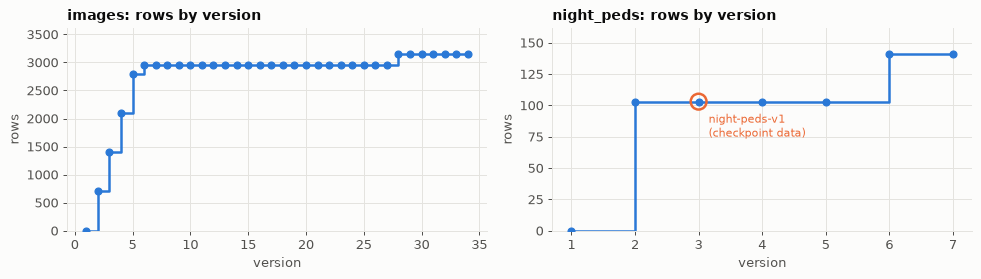

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, table, name in [(axes[0], tbl, "images"), (axes[1], night_peds, "night_peds")]:
    history = pd.DataFrame([{"version": v["version"], "rows": int(v["metadata"]["total_rows"])} for v in table.list_versions()])
    ax.step(history["version"], history["rows"], where="post", color=BLUE, lw=2)
    ax.scatter(history["version"], history["rows"], color=BLUE, s=30, zorder=3)
    ax.set_title(f"{name}: rows by version")
    ax.set_xlabel("version")
    ax.set_ylabel("rows")
    ax.set_ylim(0, history["rows"].max() * 1.15)
    if name == "night_peds":
        tag_v = table.tags.get_version("night-peds-v1")
        tag_rows = history.set_index("version").loc[tag_v, "rows"]
        ax.scatter([tag_v], [tag_rows], s=160, facecolor="none", edgecolor=ORANGE, linewidth=2, zorder=4)
        ax.annotate("night-peds-v1\n(checkpoint data)", (tag_v, tag_rows), xytext=(8, -28), textcoords="offset points", color=ORANGE, fontsize=9)
fig.tight_layout()
plt.show()

## 7. Recap

- Keep raw data, metadata and embeddings in one table.
- Add features incrementally instead of building new pipelines.
- Train from the same table you search and curate.

In [34]:
ray_session.close()   # stop the local Ray instance
print(f"Tables in {DATA_DIR.name}/: {db.table_names()}")

Tables in data/: ['images', 'night_peds']


## Running this in production

The code above runs against a local folder. [LanceDB Enterprise](https://docs.lancedb.com/enterprise) runs the same tables as a distributed service in your cloud (BYOC) or as a managed deployment, with data in object storage. Start with the [architecture overview](https://docs.lancedb.com/enterprise/architecture) or [contact the LanceDB team](https://www.lancedb.com/contact).